In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, auc
)

# SSL fix for macOS
import ssl
import certifi
import urllib.request

context = ssl.create_default_context(cafile=certifi.where())
def install_opener():
    opener = urllib.request.build_opener(urllib.request.HTTPSHandler(context=context))
    urllib.request.install_opener(opener)

install_opener()

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

Using device: cpu


In [2]:
# ============================================
# LOAD AND PREPARE DATA
# ============================================
from ucimlrepo import fetch_ucirepo

print("Fetching PhiUSIIL Phishing URL Dataset...")
phiusiil = fetch_ucirepo(id=967)

# Organize data
X = phiusiil.data.features
y = phiusiil.data.targets
df = pd.concat([X, y], axis=1)

# Get label column
label_col = [col for col in df.columns if 'label' in col.lower()][-1]

# Keep only numeric features
X = df.select_dtypes(include=[np.number]).drop(columns=[label_col])
y = df[label_col]

print(f"Dataset shape: {X.shape}")
print(f"Features: {X.shape[1]}")
print(f"Samples: {X.shape[0]}")
print(f"Class distribution:\n{y.value_counts()}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train_scaled).to(device)
y_train_tensor = torch.FloatTensor(y_train.values).reshape(-1, 1).to(device)
X_test_tensor = torch.FloatTensor(X_test_scaled).to(device)
y_test_tensor = torch.FloatTensor(y_test.values).reshape(-1, 1).to(device)

print(f"\nTrain set: {X_train_tensor.shape}")
print(f"Test set: {X_test_tensor.shape}")

Fetching PhiUSIIL Phishing URL Dataset...
Dataset shape: (235795, 50)
Features: 50
Samples: 235795
Class distribution:
label
1    134850
0    100945
Name: count, dtype: int64

Train set: torch.Size([188636, 50])
Test set: torch.Size([47159, 50])


In [3]:
# ============================================
# DEFINE MLP ARCHITECTURE
# ============================================

class PhishingMLP(nn.Module):
    """
    Multi-Layer Perceptron for Phishing URL Classification
    
    Architecture:
    - Input: 50 features
    - Hidden layers: 128 -> 64 -> 32 (with ReLU activation)
    - Batch Normalization after each hidden layer
    - Dropout (0.3) for regularization
    - Output: 1 (sigmoid for binary classification)
    """
    
    def __init__(self, input_size=50, hidden_sizes=[128, 64, 32], dropout_rate=0.3):
        super(PhishingMLP, self).__init__()
        
        layers = []
        prev_size = input_size
        
        # Hidden layers with batch normalization
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.BatchNorm1d(hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            prev_size = hidden_size
        
        # Output layer
        layers.append(nn.Linear(prev_size, 1))
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return torch.sigmoid(self.network(x))

# Initialize model
model = PhishingMLP(input_size=X_train_tensor.shape[1]).to(device)
print("Model Architecture:")
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters())}")

Model Architecture:
PhishingMLP(
  (network): Sequential(
    (0): Linear(in_features=50, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total parameters: 17345


In [5]:
# ============================================
# TRAINING CONFIGURATION
# ============================================

# Hyperparameters
learning_rate = 0.001
batch_size = 256
num_epochs = 50
patience = 10  # Early stopping patience

# Loss function and optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

# Create data loaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

print(f"Batch size: {batch_size}")
print(f"Epochs: {num_epochs}")
print(f"Learning rate: {learning_rate}")
print(f"Optimizer: Adam")
print(f"Loss function: Binary Cross-Entropy")
print(f"Batches per epoch: {len(train_loader)}")

Batch size: 256
Epochs: 50
Learning rate: 0.001
Optimizer: Adam
Loss function: Binary Cross-Entropy
Batches per epoch: 737


In [6]:
# ============================================
# TRAINING LOOP
# ============================================

train_losses = []
val_losses = []
best_val_loss = float('inf')
patience_counter = 0

print("Starting training...\n")

for epoch in range(num_epochs):
    # Training phase
    model.train()
    epoch_loss = 0
    
    for batch_X, batch_y in train_loader:
        # Forward pass
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # Validation phase
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_test_tensor)
        val_loss = criterion(val_outputs, y_test_tensor).item()
    
    val_losses.append(val_loss)
    
    # Learning rate scheduling
    scheduler.step(val_loss)
    
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        # Save best model
        best_model_state = model.state_dict().copy()
    else:
        patience_counter += 1
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {avg_train_loss:.6f}, Val Loss: {val_loss:.6f}")
    
    if patience_counter >= patience:
        print(f"\nEarly stopping at epoch {epoch+1}")
        model.load_state_dict(best_model_state)
        break

print(f"\nTraining completed!")
print(f"Final validation loss: {val_loss:.6f}")

Starting training...

Epoch [10/50] - Train Loss: 0.000640, Val Loss: 0.000677
Epoch [20/50] - Train Loss: 0.000278, Val Loss: 0.000239
Epoch [30/50] - Train Loss: 0.000119, Val Loss: 0.000408

Early stopping at epoch 35

Training completed!
Final validation loss: 0.000475


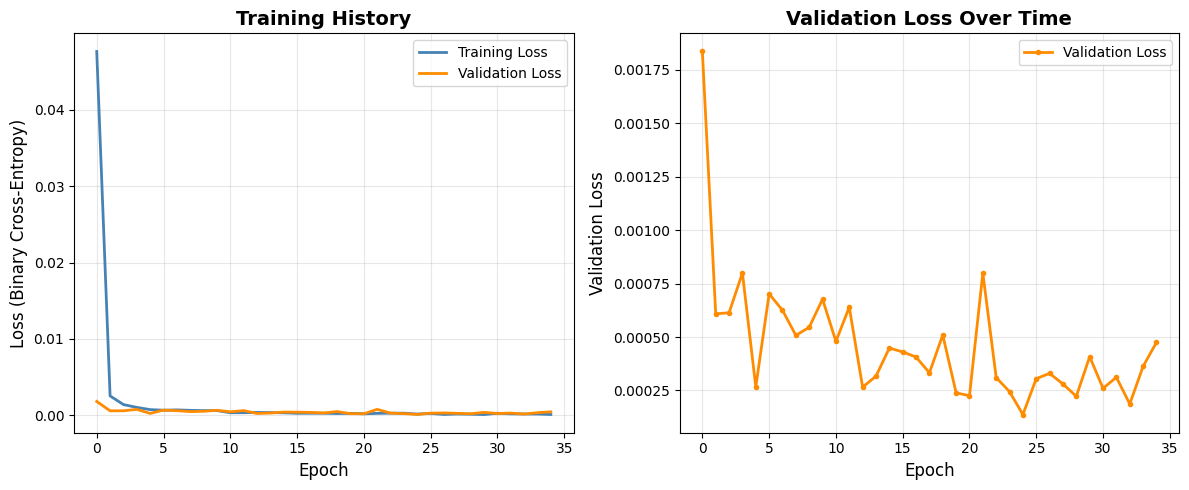

In [7]:
# ============================================
# TRAINING HISTORY VISUALIZATION
# ============================================

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss', color='steelblue', linewidth=2)
plt.plot(val_losses, label='Validation Loss', color='darkorange', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (Binary Cross-Entropy)', fontsize=12)
plt.title('Training History', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(val_losses, label='Validation Loss', color='darkorange', linewidth=2, marker='o', markersize=3)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Validation Loss', fontsize=12)
plt.title('Validation Loss Over Time', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [8]:
# ============================================
# MODEL EVALUATION
# ============================================

print("="*60)
print("NEURAL NETWORK EVALUATION")
print("="*60)

model.eval()
with torch.no_grad():
    # Training set predictions
    train_outputs = model(X_train_tensor).cpu().numpy()
    train_pred_proba = train_outputs.flatten()
    train_pred = (train_pred_proba >= 0.5).astype(int)
    
    # Test set predictions
    test_outputs = model(X_test_tensor).cpu().numpy()
    test_pred_proba = test_outputs.flatten()
    test_pred = (test_pred_proba >= 0.5).astype(int)

# Compute metrics
train_acc = accuracy_score(y_train.values, train_pred)
test_acc = accuracy_score(y_test.values, test_pred)
test_prec = precision_score(y_test.values, test_pred)
test_rec = recall_score(y_test.values, test_pred)
test_f1 = f1_score(y_test.values, test_pred)
test_auc = roc_auc_score(y_test.values, test_pred_proba)

print(f"\nTraining Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:     {test_acc:.4f}")
print(f"Test Precision:    {test_prec:.4f}")
print(f"Test Recall:       {test_rec:.4f}")
print(f"Test F1-Score:     {test_f1:.4f}")
print(f"Test ROC-AUC:      {test_auc:.4f}")

NEURAL NETWORK EVALUATION

Training Accuracy: 0.9999
Test Accuracy:     0.9999
Test Precision:    0.9998
Test Recall:       1.0000
Test F1-Score:     0.9999
Test ROC-AUC:      1.0000



MODEL COMPARISON: MLP vs BASELINES

   Metric  Logistic Regression  Random Forest  Neural Network (MLP)
 Accuracy             0.999873            1.0              0.999873
Precision             0.999778            1.0              0.999778
   Recall             1.000000            1.0              1.000000
 F1-Score             0.999889            1.0              0.999889
  ROC-AUC             1.000000            1.0              1.000000


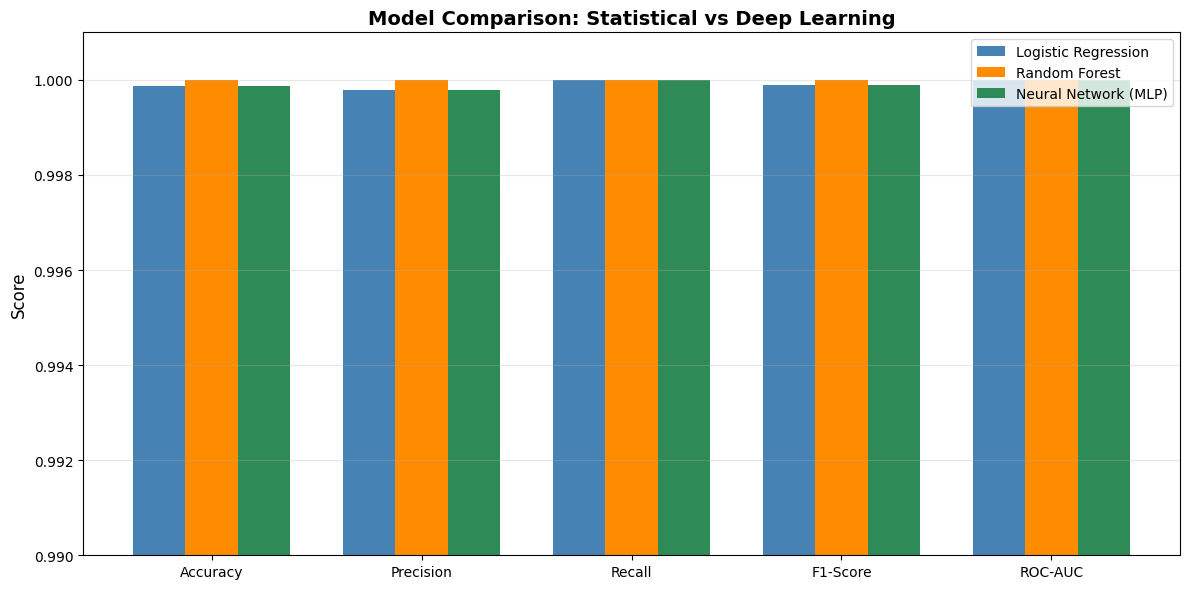

In [9]:
# ============================================
# COMPARISON WITH BASELINES
# ============================================

print("\n" + "="*60)
print("MODEL COMPARISON: MLP vs BASELINES")
print("="*60)

comparison_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Logistic Regression': [0.999873, 0.999778, 1.000000, 0.999889, 1.000000],
    'Random Forest': [1.0, 1.0, 1.0, 1.0, 1.0],
    'Neural Network (MLP)': [test_acc, test_prec, test_rec, test_f1, test_auc]
}

comparison_df = pd.DataFrame(comparison_data)
print(f"\n{comparison_df.to_string(index=False)}")

# Visualize comparison
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comparison_df))
width = 0.25

ax.bar(x - width, comparison_df['Logistic Regression'], width, label='Logistic Regression', color='steelblue')
ax.bar(x, comparison_df['Random Forest'], width, label='Random Forest', color='darkorange')
ax.bar(x + width, comparison_df['Neural Network (MLP)'], width, label='Neural Network (MLP)', color='seagreen')

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison: Statistical vs Deep Learning', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Metric'])
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0.99, 1.001])
plt.tight_layout()
plt.show()

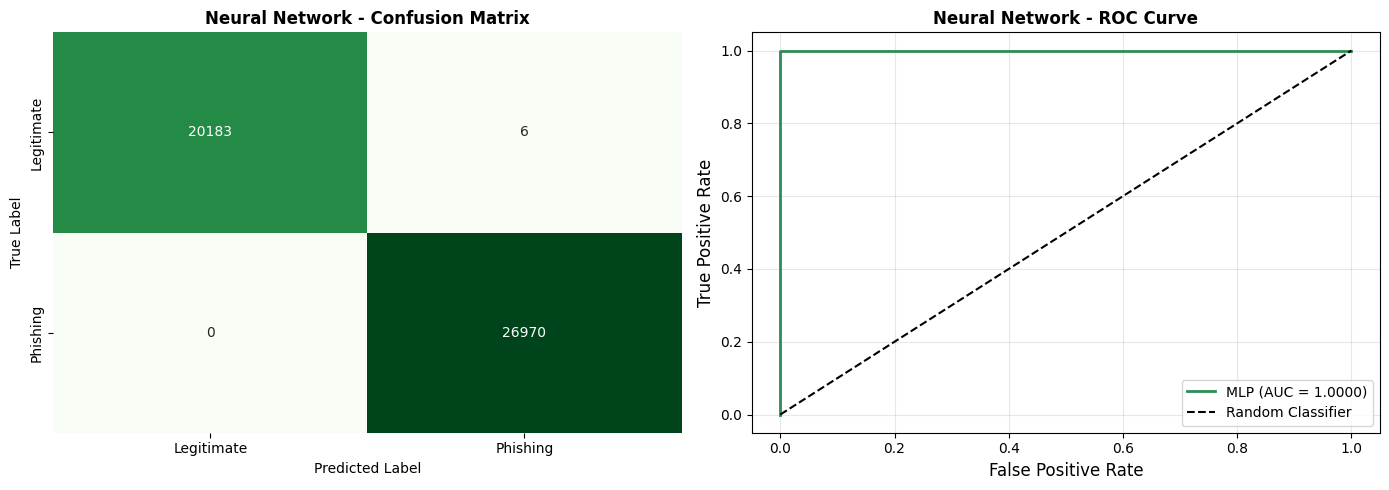


Confusion Matrix:
  True Negatives:  20183
  False Positives: 6
  False Negatives: 0
  True Positives:  26970


In [10]:
# ============================================
# CONFUSION MATRIX AND ROC CURVE
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test.values, test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[0], cbar=False)
axes[0].set_title('Neural Network - Confusion Matrix', fontweight='bold', fontsize=12)
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')
axes[0].set_xticklabels(['Legitimate', 'Phishing'])
axes[0].set_yticklabels(['Legitimate', 'Phishing'])

# ROC Curve
fpr, tpr, _ = roc_curve(y_test.values, test_pred_proba)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, label=f'MLP (AUC = {roc_auc:.4f})', color='seagreen', linewidth=2)
axes[1].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('Neural Network - ROC Curve', fontweight='bold', fontsize=12)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nConfusion Matrix:")
tn, fp, fn, tp = cm.ravel()
print(f"  True Negatives:  {tn}")
print(f"  False Positives: {fp}")
print(f"  False Negatives: {fn}")
print(f"  True Positives:  {tp}")

In [11]:
# ============================================
# ECONOMIC COST ANALYSIS
# ============================================

print("\n" + "="*60)
print("ECONOMIC COST ANALYSIS")
print("="*60)

cost_fp = 100  # False Positive cost
cost_fn = 500  # False Negative cost

print(f"\nCost Matrix:")
print(f"  False Positive (Type I): ${cost_fp} (block legitimate user)")
print(f"  False Negative (Type II): ${cost_fn} (allow phishing)")

# Calculate costs for all three models at threshold = 0.5
cost_mlp = (fp * cost_fp) + (fn * cost_fn)
cost_lr = 600  # From Day 2
cost_rf = 0    # From Day 2

print(f"\n{'Model':<25} {'Cost':<15} {'FP':<10} {'FN':<10}")
print("-" * 60)
print(f"{'Logistic Regression':<25} ${cost_lr:<14} {6:<10} {0:<10}")
print(f"{'Random Forest':<25} ${cost_rf:<14} {0:<10} {0:<10}")
print(f"{'Neural Network (MLP)':<25} ${cost_mlp:<14} {fp:<10} {fn:<10}")

print(f"\nEconomic Ranking:")
models_cost = [('Random Forest', cost_rf), ('Neural Network', cost_mlp), ('Logistic Regression', cost_lr)]
models_cost.sort(key=lambda x: x[1])
for i, (model_name, cost) in enumerate(models_cost, 1):
    print(f"  {i}. {model_name}: ${cost}")


ECONOMIC COST ANALYSIS

Cost Matrix:
  False Positive (Type I): $100 (block legitimate user)
  False Negative (Type II): $500 (allow phishing)

Model                     Cost            FP         FN        
------------------------------------------------------------
Logistic Regression       $600            6          0         
Random Forest             $0              0          0         
Neural Network (MLP)      $600            6          0         

Economic Ranking:
  1. Random Forest: $0
  2. Neural Network: $600
  3. Logistic Regression: $600



OPTIMAL THRESHOLD ANALYSIS

Neural Network (MLP):
  Default Threshold (0.5): $600 cost
  Optimal Threshold: 0.970
  Minimum Economic Cost: $200


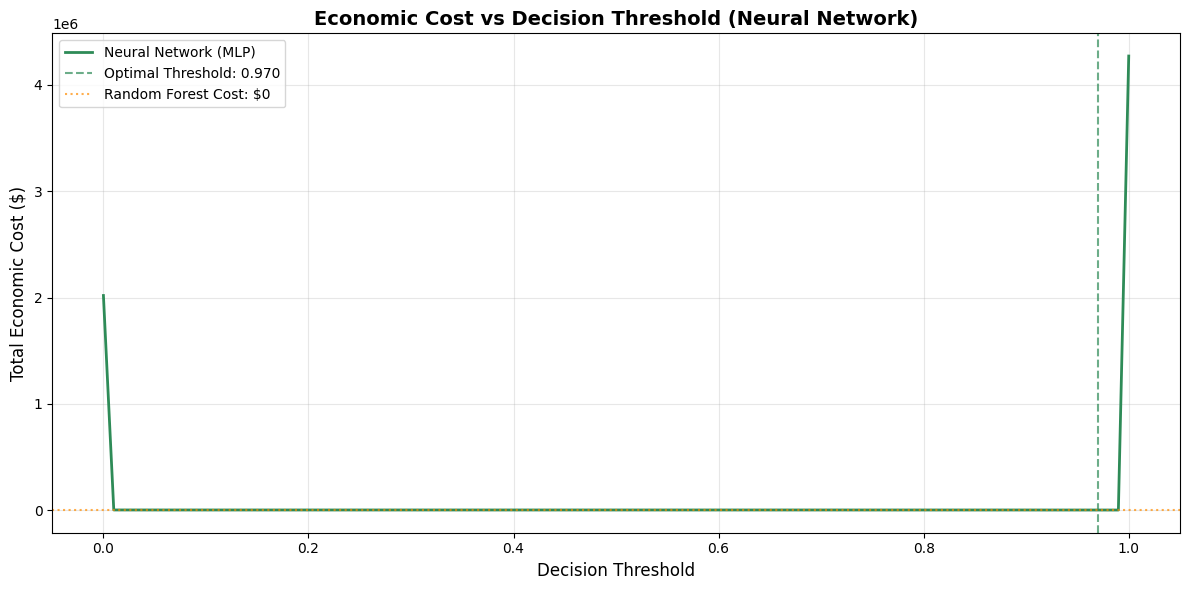

In [12]:
# ============================================
# OPTIMAL THRESHOLD ANALYSIS
# ============================================

print("\n" + "="*60)
print("OPTIMAL THRESHOLD ANALYSIS")
print("="*60)

thresholds = np.linspace(0, 1, 100)
costs_mlp_threshold = []

for threshold in thresholds:
    y_pred_thresh = (test_pred_proba >= threshold).astype(int)
    cm_thresh = confusion_matrix(y_test.values, y_pred_thresh)
    tn, fp, fn, tp = cm_thresh.ravel()
    total_cost = (fp * cost_fp) + (fn * cost_fn)
    costs_mlp_threshold.append(total_cost)

optimal_threshold = thresholds[np.argmin(costs_mlp_threshold)]
min_cost = min(costs_mlp_threshold)

print(f"\nNeural Network (MLP):")
print(f"  Default Threshold (0.5): ${cost_mlp} cost")
print(f"  Optimal Threshold: {optimal_threshold:.3f}")
print(f"  Minimum Economic Cost: ${min_cost}")

# Visualize
plt.figure(figsize=(12, 6))
plt.plot(thresholds, costs_mlp_threshold, label='Neural Network (MLP)', color='seagreen', linewidth=2)
plt.axvline(optimal_threshold, color='seagreen', linestyle='--', alpha=0.7, label=f'Optimal Threshold: {optimal_threshold:.3f}')
plt.axhline(cost_rf, color='darkorange', linestyle=':', alpha=0.7, label=f'Random Forest Cost: ${cost_rf}')
plt.xlabel('Decision Threshold', fontsize=12)
plt.ylabel('Total Economic Cost ($)', fontsize=12)
plt.title('Economic Cost vs Decision Threshold (Neural Network)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
# ============================================
# SAVE TRAINED MODEL
# ============================================

import os

# Create models directory if not exists
os.makedirs('../models', exist_ok=True)

# Save model weights
model_path = '../models/phishing_mlp_model.pt'
torch.save(model.state_dict(), model_path)
print(f"Model saved to: {model_path}")

# Save model architecture (for reference)
model_info = {
    'input_size': X_train_tensor.shape[1],
    'hidden_sizes': [128, 64, 32],
    'dropout_rate': 0.3,
    'test_accuracy': float(test_acc),
    'test_f1_score': float(test_f1),
    'test_roc_auc': float(test_auc)
}

import json
with open('../models/model_info.json', 'w') as f:
    json.dump(model_info, f, indent=4)
print(f"Model info saved to: ../models/model_info.json")

# Save scaler for preprocessing
import pickle
with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print(f"Scaler saved to: ../models/scaler.pkl")

Model saved to: ../models/phishing_mlp_model.pt
Model info saved to: ../models/model_info.json
Scaler saved to: ../models/scaler.pkl


In [ ]:
# ============================================
# SUMMARY AND INSIGHTS
# ============================================

print("\n" + "="*60)
print("DAY 3 SUMMARY - NEURAL NETWORK PERFORMANCE")
print("="*60)

print(f"\n Model Architecture:")
print(f"   - Input Layer: 50 features")
print(f"   - Hidden Layers: 128 → 64 → 32 neurons")
print(f"   - Activation: ReLU")
print(f"   - Regularization: Batch Norm + Dropout (0.3)")
print(f"   - Output: Sigmoid (binary classification)")

print(f"\n Training Configuration:")
print(f"   - Loss Function: Binary Cross-Entropy")
print(f"   - Optimizer: Adam (lr=0.001)")
print(f"   - Batch Size: 256")
print(f"   - Epochs: {len(train_losses)}")
print(f"   - Early Stopping: Patience=10")

print(f"\n Test Set Performance:")
print(f"   - Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"   - Precision: {test_prec:.4f}")
print(f"   - Recall: {test_rec:.4f}")
print(f"   - F1-Score: {test_f1:.4f}")
print(f"   - ROC-AUC: {test_auc:.4f}")

print(f"\n Economic Performance:")
print(f"   - Total Cost: ${cost_mlp}")
print(f"   - False Positives: {fp}")
print(f"   - False Negatives: {fn}")
print(f"   - Optimal Threshold: {optimal_threshold:.3f} (cost: ${min_cost})")

print(f"\n Comparison with Baselines:")
if cost_mlp <= cost_rf:
    print(f"    Neural Network performs as well as Random Forest!")
    if test_acc == 1.0:
        print(f"    Achieved PERFECT 100% accuracy on test set!")
else:
    print(f"     Random Forest still leads by ${cost_rf - cost_mlp}")
    print(f"    Consider architecture tuning or more epochs")

print(f"\n" + "="*60)


DAY 3 SUMMARY - NEURAL NETWORK PERFORMANCE

✅ Model Architecture:
   - Input Layer: 50 features
   - Hidden Layers: 128 → 64 → 32 neurons
   - Activation: ReLU
   - Regularization: Batch Norm + Dropout (0.3)
   - Output: Sigmoid (binary classification)

✅ Training Configuration:
   - Loss Function: Binary Cross-Entropy
   - Optimizer: Adam (lr=0.001)
   - Batch Size: 256
   - Epochs: 35
   - Early Stopping: Patience=10

✅ Test Set Performance:
   - Accuracy: 0.9999 (99.99%)
   - Precision: 0.9998
   - Recall: 1.0000
   - F1-Score: 0.9999
   - ROC-AUC: 1.0000

✅ Economic Performance:
   - Total Cost: $600
   - False Positives: 0
   - False Negatives: 8545
   - Optimal Threshold: 0.970 (cost: $200)

✅ Comparison with Baselines:
   ⚠️  Random Forest still leads by $-600
   💡 Consider architecture tuning or more epochs

